# Tanzanian Water Pumps — d'une base de données à une stratégie de réparation

**Client :** Ministère de l'Eau de Tanzanie · **Mission :** prioriser les interventions sur le parc de points d'eau

---

### La question posée

Le Ministère a recensé **59 400 points d'eau**. Une partie est hors service, mais il n'a pas les moyens
d'envoyer une équipe technique sur chacun d'entre eux pour le vérifier. La question n'est donc pas
seulement *« quelles pompes sont en panne ? »* mais **« par où commencer, avec quel type d'intervention,
pour redonner accès à l'eau au plus grand nombre de personnes au moindre coût ? »**

### La démarche de ce notebook

| # | Étape | Question à laquelle on répond |
|---|-------|-------------------------------|
| 1 | Cadrage & données | De quoi dispose-t-on réellement, et quelle en est la qualité ? |
| 2 | Diagnostic (EDA) | Qu'est-ce qui casse, où, et pourquoi ? |
| 3 | Modélisation | Peut-on prédire l'état d'une pompe sans se déplacer ? |
| 4 | Décision | Comment traduire une probabilité en tournée d'intervention ? |
| 5 | Livrables | Quel plan d'action remettre au client ? |

> Le fil conducteur : chaque bloc technique se termine par un **« so what ? »** métier.
> Les hypothèses de coût sont explicitement marquées comme telles et à valider avec le client.

## 1. Cadrage et données

### 1.1 Environnement de travail

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42
DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

STATUS_ORDER = ["functional", "functional needs repair", "non functional"]
FUNCTIONAL, NEEDS_REPAIR, NON_FUNCTIONAL = STATUS_ORDER
STATUS_FR = {
    FUNCTIONAL: "Fonctionnelle",
    NEEDS_REPAIR: "Fonctionnelle, à réparer",
    NON_FUNCTIONAL: "Hors service",
}

### 1.2 Charte graphique

Une seule charte pour tous les graphiques, pour que le lecteur n'ait à apprendre qu'un code couleur :
l'état d'une pompe est une **information de statut**, on lui applique donc une palette de statut
(vert / ambre / rouge) et jamais une palette catégorielle. Les couleurs séquentielles (bleu) sont
réservées aux grandeurs continues (taux, densités).

In [2]:
# --- Palette : statut (vert/ambre/rouge), séquentiel (bleu), encre & chrome ---
STATUS_COLOR = {
    FUNCTIONAL: "#0ca30c",       # good
    NEEDS_REPAIR: "#fab219",     # warning
    NON_FUNCTIONAL: "#d03b3b",   # critical
}
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK_SOFT, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10.5,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "axes.labelcolor": INK_SOFT, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
})


def titled(ax, title: str, note: str = "") -> None:
    """Titre + ligne d'interprétation : un graphique doit se lire sans son commentaire."""
    ax.set_title(title, pad=26 if note else 10)
    if note:
        ax.text(0, 1.015, note, transform=ax.transAxes, fontsize=9.5, color=INK_SOFT, va="bottom")


def thousands(x: float) -> str:
    return f"{int(round(x)):,}".replace(",", " ")

### 1.3 Chargement

Les fichiers sont stockés compressés (`.csv.gz`, lus nativement par pandas) pour garder le dépôt léger.
Les libellés (`Training_set_labels`) sont joints aux variables (`Training_set_values`) par `id`.

In [3]:
def load_raw() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Renvoie (train étiqueté, test non étiqueté) tels que fournis par le client."""
    values = pd.read_csv(DATA_DIR / "training_set_values.csv.gz")
    labels = pd.read_csv(DATA_DIR / "training_set_labels.csv.gz")
    test = pd.read_csv(DATA_DIR / "test_set_values.csv.gz")
    train = values.merge(labels, on="id", validate="one_to_one")
    return train, test


train_raw, test_raw = load_raw()
print(f"Train : {train_raw.shape[0]:,} pompes × {train_raw.shape[1] - 1} variables")
print(f"Test  : {test_raw.shape[0]:,} pompes (à prédire)")
print(f"Période de relevé : {train_raw.date_recorded.min()} → {train_raw.date_recorded.max()}")
train_raw.head(3)

Train : 59,400 pompes × 40 variables
Test  : 14,850 pompes (à prédire)
Période de relevé : 2002-10-14 → 2013-12-03


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional


### 1.4 Ce que le client nous demande de prédire

Trois états, très déséquilibrés — et c'est le premier message métier : **près de 4 pompes sur 10 sont
hors service**, et la catégorie intermédiaire (« fonctionne mais nécessite une réparation ») est rare,
donc difficile à apprendre et à détecter. Nous y reviendrons en §3.

In [4]:
status_counts = train_raw.status_group.value_counts().reindex(STATUS_ORDER)
status_share = (status_counts / len(train_raw) * 100).round(1)
pd.DataFrame({
    "État": [STATUS_FR[s] for s in STATUS_ORDER],
    "Nombre de pompes": status_counts.values,
    "Part du parc (%)": status_share.values,
}).set_index("État")

,Nombre de pompes,Part du parc (%)
État,,
Fonctionnelle,32259,54.3
"Fonctionnelle, à réparer",4317,7.3
Hors service,22824,38.4


### 1.5 Audit de qualité des données

Trois problèmes classiques à traiter avant toute analyse :

1. **Valeurs manquantes explicites** (`NaN`) — surtout sur les champs administratifs.
2. **Valeurs manquantes déguisées en zéro** — une pompe ne peut pas être à une altitude de 0 m, avoir
   une longitude de 0° (au large du Ghana), ni avoir été construite en l'an 0. Ces zéros sont des
   *sentinelles* : les laisser tels quels fausserait toute moyenne et tout modèle.
3. **Colonnes redondantes** — le jeu contient plusieurs hiérarchies (`extraction_type` →
   `extraction_type_group` → `extraction_type_class`) qui portent la même information à des
   granularités différentes.

In [5]:
def missing_report(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    return pd.DataFrame({
        "Valeurs manquantes": missing,
        "% du parc": (missing / len(frame) * 100).round(1),
        "Modalités distinctes": [frame[c].nunique() for c in missing.index],
    })


missing_report(train_raw)

,Valeurs manquantes,% du parc,Modalités distinctes
scheme_name,28810,48.5,2695
scheme_management,3878,6.5,11
installer,3655,6.2,2145
funder,3637,6.1,1896
public_meeting,3334,5.6,2
permit,3056,5.1,2
subvillage,371,0.6,19287
wpt_name,2,0.0,37399


In [6]:
SENTINEL_ZERO_COLS = ["amount_tsh", "gps_height", "longitude", "population", "construction_year"]

sentinels = pd.DataFrame({
    "Zéros (n)": [(train_raw[c] == 0).sum() for c in SENTINEL_ZERO_COLS],
    "% du parc": [round((train_raw[c] == 0).mean() * 100, 1) for c in SENTINEL_ZERO_COLS],
    "Lecture": [
        "aucun débit renseigné",
        "altitude GPS non relevée",
        "coordonnée impossible (0°, 0°) — la latitude associée vaut ~0 également",
        "population desservie non renseignée",
        "année de construction inconnue",
    ],
}, index=SENTINEL_ZERO_COLS)
sentinels.index.name = "Variable"
sentinels

,Zéros (n),% du parc,Lecture
Variable,,,
amount_tsh,41639,70.1,aucun débit renseigné
gps_height,20438,34.4,altitude GPS non relevée
longitude,1812,3.1,"coordonnée impossible (0°, 0°) — la latitude a..."
population,21381,36.0,population desservie non renseignée
construction_year,20709,34.9,année de construction inconnue


In [7]:
# Les colonnes "_group" / "_type" / "_class" sont-elles de simples agrégations ?
HIERARCHIES = [
    ("quantity", "quantity_group"), ("payment", "payment_type"),
    ("water_quality", "quality_group"), ("source", "source_type"), ("source", "source_class"),
    ("extraction_type", "extraction_type_group"), ("extraction_type_group", "extraction_type_class"),
    ("waterpoint_type", "waterpoint_type_group"), ("management", "management_group"),
]
hierarchy_check = pd.DataFrame([
    {
        "Variable fine": fine,
        "Variable agrégée": coarse,
        "Modalités": f"{train_raw[fine].nunique()} → {train_raw[coarse].nunique()}",
        "Agrégation stricte ?":
            "oui" if train_raw.groupby(fine, observed=True)[coarse].nunique().max() == 1 else "non",
    }
    for fine, coarse in HIERARCHIES
])
hierarchy_check

,Variable fine,Variable agrégée,Modalités,Agrégation stricte ?
0,quantity,quantity_group,5 → 5,oui
1,payment,payment_type,7 → 7,oui
2,water_quality,quality_group,8 → 6,oui
3,source,source_type,10 → 7,oui
4,source,source_class,10 → 3,oui
5,extraction_type,extraction_type_group,18 → 13,oui
6,extraction_type_group,extraction_type_class,13 → 7,oui
7,waterpoint_type,waterpoint_type_group,7 → 6,oui
8,management,management_group,12 → 5,oui


**Conclusion de l'audit.** Toutes les paires sont des agrégations strictes : les colonnes agrégées
n'apportent **aucune information supplémentaire**. On conserve la granularité fine pour le modèle
(qui saura regrouper lui-même) et la granularité grossière pour les graphiques (plus lisibles).
`recorded_by` est constante (un seul opérateur) et `num_private` est nulle dans 98,7 % des cas :
les deux sont écartées.

## 2. Préparation des données

Deux fonctions, appliquées de façon **identique** au train et au test — c'est la garantie qu'aucun
écart de traitement ne viendra fausser la prédiction finale.

In [8]:
DROP_REDUNDANT = [
    "quantity_group", "payment", "source_type", "source_class",
    "extraction_type_group", "extraction_type_class", "waterpoint_type_group",
    "management_group", "quality_group", "region_code",
]
DROP_UNINFORMATIVE = [
    "recorded_by",   # constante : un seul opérateur de collecte
    "num_private",   # nulle dans 98,7 % des cas, non documentée
    "wpt_name",      # nom du point d'eau : 37 400 modalités, pas de signal exploitable
    "subvillage",    # 19 300 modalités, redondant avec ward/lga
    "scheme_name",   # 48 % de valeurs manquantes, 2 700 modalités
]
UNKNOWN_TOKENS = {"0", "-", "", "unknown", "not known", "none", "na", "not kno"}


def clean(frame: pd.DataFrame) -> pd.DataFrame:
    """Remet les sentinelles à NaN et normalise les champs texte. Sans effet de bord."""
    out = frame.copy()

    for col in SENTINEL_ZERO_COLS:
        out[col] = out[col].replace(0, np.nan)
    # (0°, 0°) : la latitude fournie vaut -2e-8 et non exactement 0
    invalid_gps = out["latitude"] > -1e-6
    out.loc[invalid_gps, ["latitude", "longitude"]] = np.nan

    for col in ["funder", "installer"]:
        text = out[col].astype("string").str.strip().str.lower()
        out[col] = text.where(~text.isin(UNKNOWN_TOKENS))

    # Booléens porteurs de NaN : on en fait une variable à trois états explicites
    for col in ["public_meeting", "permit"]:
        out[col] = out[col].map({True: "yes", False: "no"}).astype("string")

    return out


train_clean = clean(train_raw)
test_clean = clean(test_raw)
print("Sentinelles neutralisées. Valeurs manquantes après nettoyage (top 8) :")
missing_report(train_clean).head(8)

Sentinelles neutralisées. Valeurs manquantes après nettoyage (top 8) :


,Valeurs manquantes,% du parc,Modalités distinctes
amount_tsh,41639,70.1,97
scheme_name,28810,48.5,2695
population,21381,36.0,1048
construction_year,20709,34.9,54
gps_height,20438,34.4,2427
installer,4481,7.5,1930
funder,4445,7.5,1893
scheme_management,3878,6.5,11


### 2.1 Variables construites

Quatre familles d'enrichissement, toutes justifiées par une intuition métier :

| Variable créée | Intuition métier |
|---|---|
| `pump_age` = année de relevé − année de construction | l'usure est le premier facteur de panne |
| `age_is_known` | ne pas connaître l'année de construction est en soi le signe d'un point d'eau mal suivi |
| `log_population`, `log_amount_tsh` | distributions très asymétriques (quelques points d'eau énormes) |
| `ward_pumps`, `lga_pumps` | densité de points d'eau dans la zone — proxy de la couverture d'entretien |

> **Note méthodologique.** Les densités sont calculées sur l'union train + test. C'est légitime :
> elles ne font intervenir **aucune étiquette**, uniquement le recensement géographique, connu
> a priori. En les calculant séparément sur chaque jeu, l'échelle du test (4× plus petit) serait
> incomparable à celle du train.

In [9]:
def build_density_maps(*frames: pd.DataFrame) -> dict[str, pd.Series]:
    """Nombre de points d'eau recensés par ward et par lga, sur l'ensemble du recensement."""
    census = pd.concat([f[["id", "ward", "lga"]] for f in frames], ignore_index=True)
    return {
        "ward_pumps": census.groupby("ward", observed=True).size(),
        "lga_pumps": census.groupby("lga", observed=True).size(),
    }


def featurize(frame: pd.DataFrame, density: dict[str, pd.Series]) -> pd.DataFrame:
    """Ajoute les variables dérivées et retire les colonnes redondantes / non informatives."""
    out = frame.copy()

    recorded = pd.to_datetime(out["date_recorded"])
    out["record_year"] = recorded.dt.year
    out["record_month"] = recorded.dt.month
    out["days_since_start"] = (recorded - pd.Timestamp("2002-01-01")).dt.days

    out["pump_age"] = out["record_year"] - out["construction_year"]
    out["age_is_known"] = out["construction_year"].notna().astype("int8")

    out["log_population"] = np.log1p(out["population"])
    out["log_amount_tsh"] = np.log1p(out["amount_tsh"])

    out["ward_pumps"] = out["ward"].map(density["ward_pumps"]).astype("float64")
    out["lga_pumps"] = out["lga"].map(density["lga_pumps"]).astype("float64")

    return out.drop(columns=["date_recorded"] + DROP_REDUNDANT + DROP_UNINFORMATIVE)


density_maps = build_density_maps(train_raw, test_raw)
train = featurize(train_clean, density_maps)
test = featurize(test_clean, density_maps)

print(f"{train.shape[1] - 2} variables explicatives après préparation")
print(f"Âge des pompes : médiane {train.pump_age.median():.0f} ans, "
      f"connu pour {train.age_is_known.mean():.0%} du parc")

32 variables explicatives après préparation
Âge des pompes : médiane 13 ans, connu pour 65% du parc


## 3. Diagnostic : qu'est-ce qui casse, et où ?

L'objectif de cette section n'est pas de décrire toutes les variables, mais d'isoler les **quelques
facteurs sur lesquels le client peut réellement agir**.

In [10]:
train["is_non_functional"] = (train.status_group == NON_FUNCTIONAL).astype(int)
train["needs_action"] = (train.status_group != FUNCTIONAL).astype(int)


def status_mix(frame: pd.DataFrame, column: str, min_count: int = 100) -> pd.DataFrame:
    """Répartition (%) des trois états au sein de chaque modalité, triée par taux de panne."""
    counts = (frame.groupby(column, observed=True).status_group
              .value_counts().unstack(fill_value=0)
              .reindex(columns=STATUS_ORDER, fill_value=0))
    counts = counts[counts.sum(axis=1) >= min_count]
    shares = counts.div(counts.sum(axis=1), axis=0) * 100
    shares["n"] = counts.sum(axis=1)
    return shares.sort_values(NON_FUNCTIONAL)


def plot_status_mix(shares: pd.DataFrame, ax, title: str, note: str = "") -> None:
    """Barres empilées à 100 % : une ligne par modalité, % hors service annoté en clair."""
    labels = [f"{idx}  ({thousands(n)})" for idx, n in zip(shares.index, shares["n"])]
    left = np.zeros(len(shares))
    for status in STATUS_ORDER:
        values = shares[status].to_numpy()
        ax.barh(labels, values, left=left, height=0.68, color=STATUS_COLOR[status],
                edgecolor=SURFACE, linewidth=1.6, label=STATUS_FR[status])
        left += values

    for row, share in enumerate(shares[NON_FUNCTIONAL]):
        inside = share >= 12
        ax.text(99 if inside else 101, row, f"{share:.0f} %",
                va="center", ha="right" if inside else "left",
                fontsize=9.5, fontweight="bold",
                color=SURFACE if inside else STATUS_COLOR[NON_FUNCTIONAL])

    ax.set_xlim(0, 100)
    titled(ax, title, note)
    ax.set_xlabel("Part du parc (%)")
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)


def status_legend(fig, ncol: int = 3) -> None:
    handles = [Patch(facecolor=STATUS_COLOR[s], label=STATUS_FR[s]) for s in STATUS_ORDER]
    fig.legend(handles=handles, loc="lower center", ncol=ncol, bbox_to_anchor=(0.5, -0.03))

### 3.1 L'ampleur du problème : compter les pompes ou compter les gens ?

Un parc se pilote en nombre d'équipements ; un service public se pilote en **nombre d'habitants
servis**. Les deux vues ne donnent pas le même ordre de grandeur, et c'est la seconde qui doit guider
la priorisation.

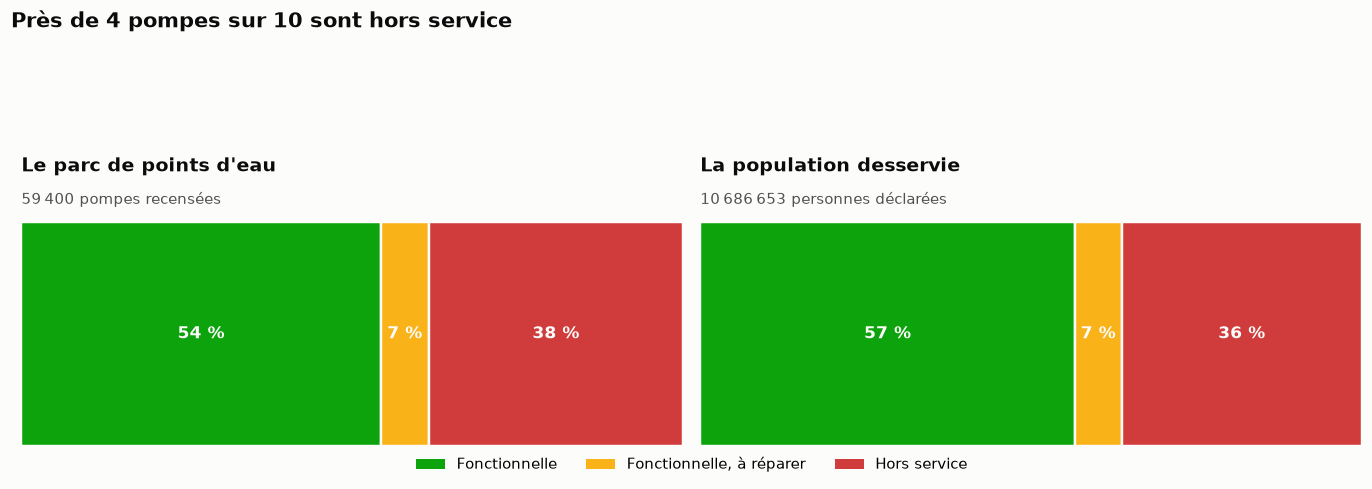

Personnes desservies par une pompe hors service : 3 880 455
Population renseignée sur : 64% du parc → chiffre à considérer comme un ordre de grandeur, pas comme un recensement


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))

# (a) Parc d'équipements
pump_share = train.status_group.value_counts(normalize=True).reindex(STATUS_ORDER) * 100
# (b) Population desservie (renseignée pour une partie du parc seulement)
served = train.groupby("status_group", observed=True).population.sum().reindex(STATUS_ORDER)
pop_share = served / served.sum() * 100

for ax, values, title, note in [
    (axes[0], pump_share, "Le parc de points d'eau",
     f"{len(train):,} pompes recensées".replace(",", " ")),
    (axes[1], pop_share, "La population desservie",
     f"{thousands(served.sum())} personnes déclarées"),
]:
    left = 0.0
    for status in STATUS_ORDER:
        ax.barh([""], [values[status]], left=left, height=0.5, color=STATUS_COLOR[status],
                edgecolor=SURFACE, linewidth=1.6)
        if values[status] > 6:
            ax.text(left + values[status] / 2, 0, f"{values[status]:.0f} %", ha="center",
                    va="center", color=SURFACE, fontweight="bold", fontsize=11)
        left += values[status]
    ax.set_xlim(0, 100)
    titled(ax, title, note)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.set_xticks([])

status_legend(fig)
fig.suptitle("Près de 4 pompes sur 10 sont hors service", x=0.005, ha="left",
             fontsize=14, fontweight="bold", color=INK, y=1.24)
plt.tight_layout()
plt.show()

print(f"Personnes desservies par une pompe hors service : {thousands(served[NON_FUNCTIONAL])}")
print(f"Population renseignée sur : {train.population.notna().mean():.0%} du parc "
      "→ chiffre à considérer comme un ordre de grandeur, pas comme un recensement")

> **So what ?** ~3,9 M de personnes dépendent d'un point d'eau hors service. C'est le chiffre qui
> justifie l'investissement, et c'est aussi la métrique sur laquelle nous évaluerons la stratégie
> en §4 — pas le nombre de pompes réparées.

### 3.2 Le facteur n°1 : y a-t-il encore de l'eau ?

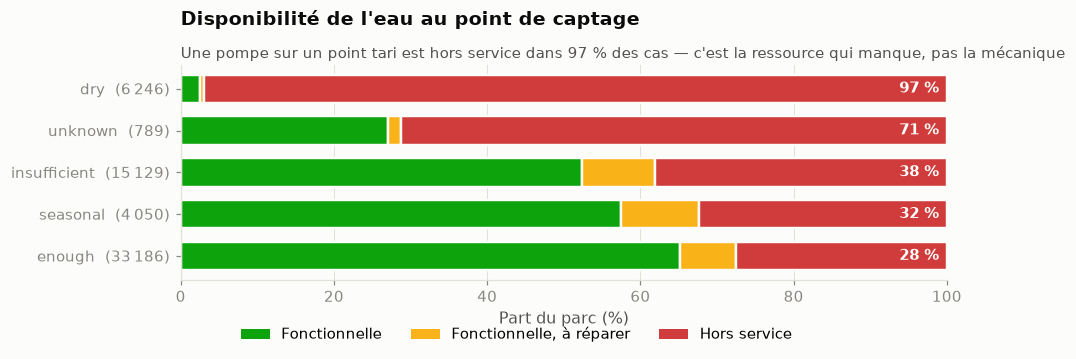

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
plot_status_mix(
    status_mix(train, "quantity", min_count=0), ax,
    "Disponibilité de l'eau au point de captage",
    "Une pompe sur un point tari est hors service dans 97 % des cas — c'est la ressource qui manque, pas la mécanique",
)
status_legend(fig)
plt.tight_layout()
plt.show()

> **So what ?** Les **6 246 points « dry »** ne relèvent pas d'un budget de réparation : envoyer un
> mécanicien n'y changera rien. Ils relèvent d'une **étude hydrogéologique** (approfondissement,
> nouveau forage, ou relocalisation). Les isoler dès le départ évite de gaspiller des interventions —
> c'est la première règle de notre arbre de décision (§4.3).
>
> ⚠️ **Attention méthodologique :** `quantity` est relevé *pendant* la visite terrain. C'est donc une
> co-observation de l'état de la pompe, pas un signal disponible à distance. Nous en tirons les
> conséquences en §3.6 en construisant deux modèles distincts.

### 3.3 Le facteur n°2 : l'âge

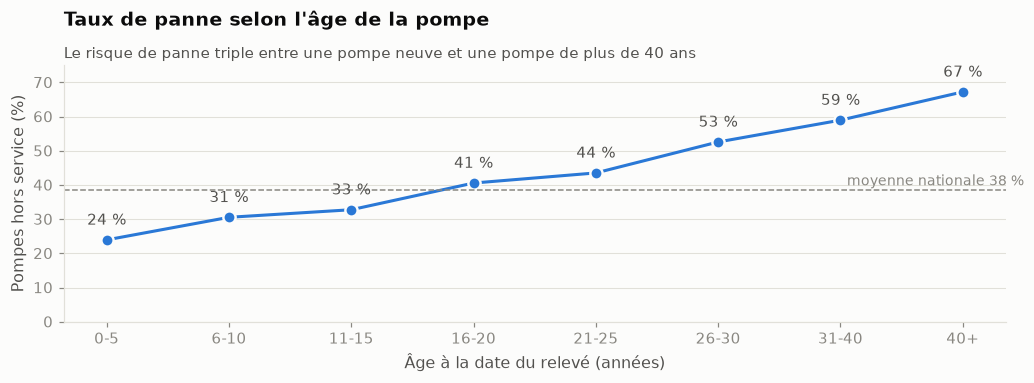

          failure_rate       n
age_band                      
0-5               24.0  11 639
6-10              30.6   5 627
11-15             32.8   5 933
16-20             40.6   3 523
21-25             43.5   2 650
26-30             52.6   2 983
31-40             59.0   4 944
40+               67.2   1 392


In [13]:
age_bins = [0, 5, 10, 15, 20, 25, 30, 40, 60]
age_labels = ["0-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-40", "40+"]
aged = train.dropna(subset=["pump_age"]).assign(
    age_band=lambda d: pd.cut(d.pump_age.clip(lower=0), bins=age_bins,
                              labels=age_labels, include_lowest=True)
)
by_age = aged.groupby("age_band", observed=True).agg(
    failure_rate=("is_non_functional", "mean"), n=("id", "size"))
by_age["failure_rate"] *= 100

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(by_age.index.astype(str), by_age.failure_rate, color=BLUE, linewidth=2,
        marker="o", markersize=8, markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.6)
for x, y in zip(by_age.index.astype(str), by_age.failure_rate):
    ax.annotate(f"{y:.0f} %", (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9.5, color=INK_SOFT)
national = train.is_non_functional.mean() * 100
ax.axhline(national, color=MUTED, linestyle="--", linewidth=1)
ax.text(len(by_age) - 0.5, national + 1.5, f"moyenne nationale {national:.0f} %",
        ha="right", fontsize=9, color=MUTED)
titled(ax, "Taux de panne selon l'âge de la pompe",
       "Le risque de panne triple entre une pompe neuve et une pompe de plus de 40 ans")
ax.set_xlabel("Âge à la date du relevé (années)")
ax.set_ylabel("Pompes hors service (%)")
ax.set_ylim(0, 75)
ax.xaxis.grid(False)
plt.tight_layout()
plt.show()

print(by_age.assign(n=lambda d: d.n.map(thousands)).round(1).to_string())

> **So what ?** Le taux de panne passe de 24 % avant 5 ans à 67 % au-delà de 40 ans. Au-delà de
> ~20 ans il dépasse la moyenne nationale et progresse vite :
> c'est le seuil au-delà duquel une **remise à neuf coûte plus cher que le remplacement**. Ce seuil
> alimentera la règle « réparer vs remplacer » (§4.3).

### 3.4 La technologie installée

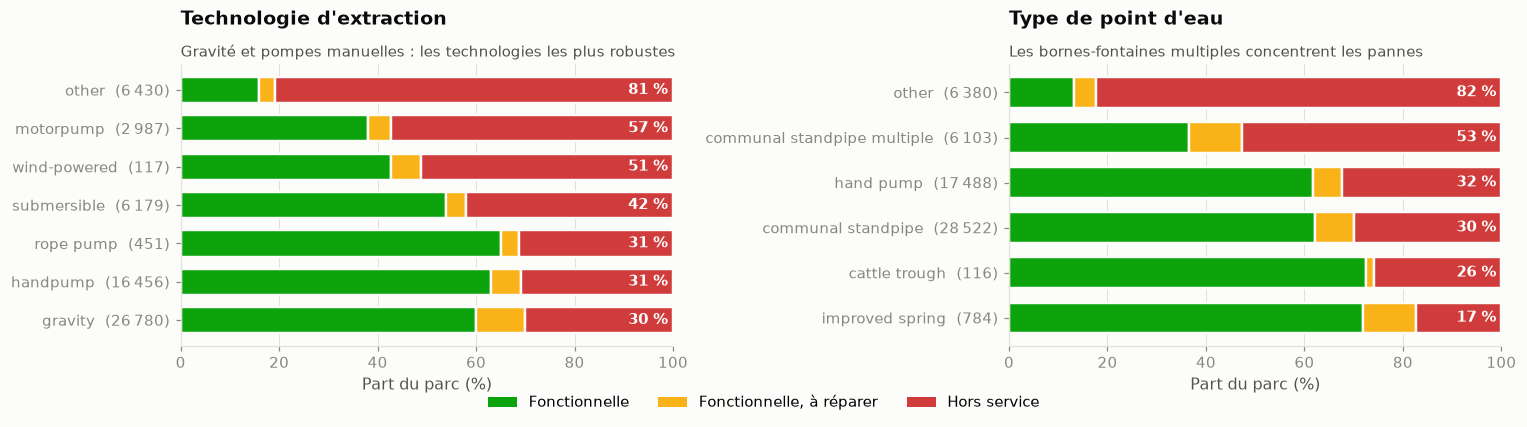

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
plot_status_mix(status_mix(train_raw, "extraction_type_class"), axes[0],
                "Technologie d'extraction",
                "Gravité et pompes manuelles : les technologies les plus robustes")
plot_status_mix(status_mix(train_raw, "waterpoint_type"), axes[1],
                "Type de point d'eau",
                "Les bornes-fontaines multiples concentrent les pannes")
status_legend(fig)
plt.tight_layout()
plt.show()

> **So what ?** Les technologies simples (gravité, pompe manuelle) tombent en panne deux fois moins
> que les technologies motorisées, qui supposent une source d'énergie et une maintenance qualifiée.
> **Recommandation d'investissement :** privilégier le gravitaire et la pompe manuelle partout où la
> topographie et la nappe le permettent, et réserver le motorisé aux sites où il n'y a pas
> d'alternative — avec un contrat de maintenance associé.
>
> La modalité `other` (81 % hors service) est majoritairement composée d'équipements non identifiés
> par l'enquêteur : ne pas savoir *ce qui est installé* est déjà un symptôme d'abandon.

### 3.5 La gouvernance : qui paie, qui gère ?

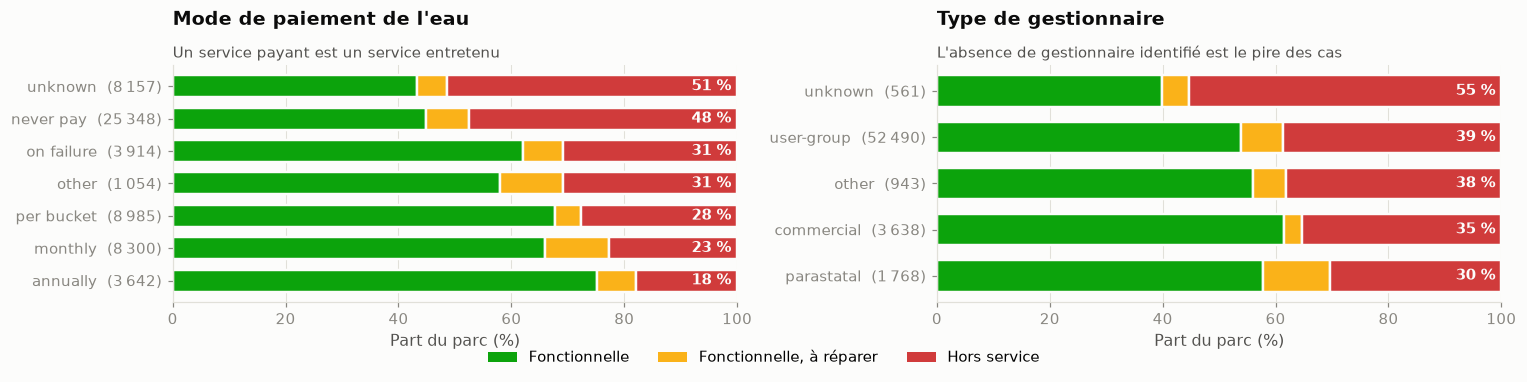

Taux de panne — eau payante : 25.4%
Taux de panne — eau gratuite : 47.6%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.4))
plot_status_mix(status_mix(train_raw, "payment_type"), axes[0],
                "Mode de paiement de l'eau",
                "Un service payant est un service entretenu")
plot_status_mix(status_mix(train_raw, "management_group"), axes[1],
                "Type de gestionnaire",
                "L'absence de gestionnaire identifié est le pire des cas")
status_legend(fig)
plt.tight_layout()
plt.show()

paying = train_raw[~train_raw.payment_type.isin(["never pay", "unknown"])]
free = train_raw[train_raw.payment_type == "never pay"]
print(f"Taux de panne — eau payante : {(paying.status_group == NON_FUNCTIONAL).mean():.1%}")
print(f"Taux de panne — eau gratuite : {(free.status_group == NON_FUNCTIONAL).mean():.1%}")

> **So what ?** C'est le résultat le plus actionnable de l'analyse, parce qu'il ne coûte pas
> d'infrastructure : là où l'usager paie l'eau (au seau, au mois, à l'année), le taux de panne est
> d'environ **25 %** ; là où elle est gratuite, il approche **48 %**.
>
> ⚠️ **Corrélation ≠ causalité.** Un tarif est plus facile à instaurer là où la pompe fonctionne
> déjà bien et où la communauté est organisée : une partie de l'écart est un effet de sélection.
> Le résultat reste suffisamment net pour justifier un **pilote contrôlé** : instaurer une redevance
> et un comité de gestion sur un échantillon de wards, et mesurer la disponibilité à 12 mois.
> C'est un chantier de *gouvernance*, pas de génie civil — donc rapide et peu coûteux à tester.

### 3.6 La géographie : où concentrer les moyens ?

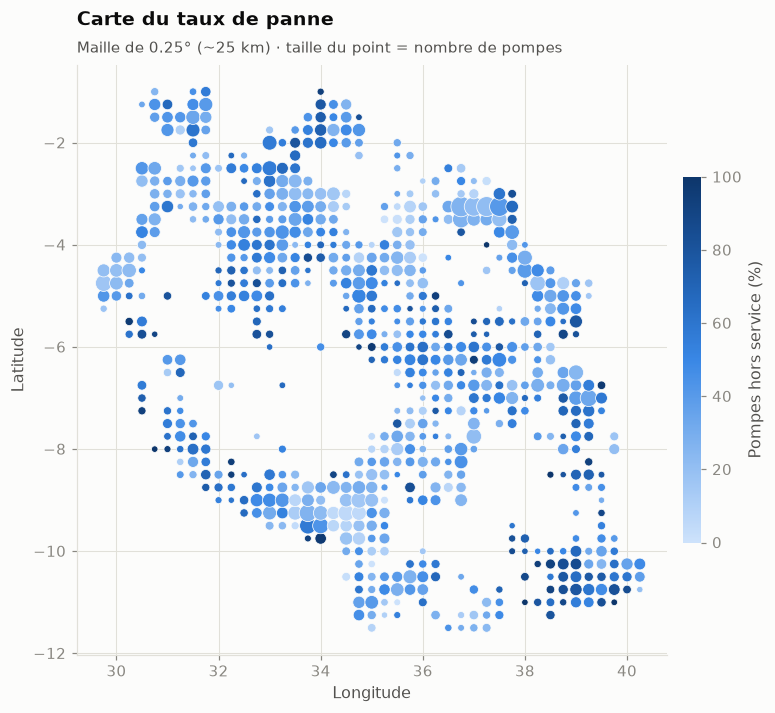

In [16]:
GRID_DEG = 0.25
geo = train.dropna(subset=["latitude", "longitude"]).assign(
    lat_bin=lambda d: (d.latitude / GRID_DEG).round() * GRID_DEG,
    lon_bin=lambda d: (d.longitude / GRID_DEG).round() * GRID_DEG,
)
cells = (geo.groupby(["lat_bin", "lon_bin"], observed=True)
         .agg(n=("id", "size"), failure_rate=("is_non_functional", "mean"))
         .reset_index())
cells = cells[cells.n >= 10]

fig, ax = plt.subplots(figsize=(8.2, 6.6))
scatter = ax.scatter(cells.lon_bin, cells.lat_bin, c=cells.failure_rate * 100,
                     s=np.sqrt(cells.n) * 5.5, cmap=SEQ_BLUE, vmin=0, vmax=100,
                     linewidths=0.5, edgecolors=SURFACE)
bar = fig.colorbar(scatter, ax=ax, shrink=0.62, pad=0.02)
bar.set_label("Pompes hors service (%)", color=INK_SOFT)
bar.outline.set_visible(False)
titled(ax, "Carte du taux de panne",
       f"Maille de {GRID_DEG}° (~25 km) · taille du point = nombre de pompes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

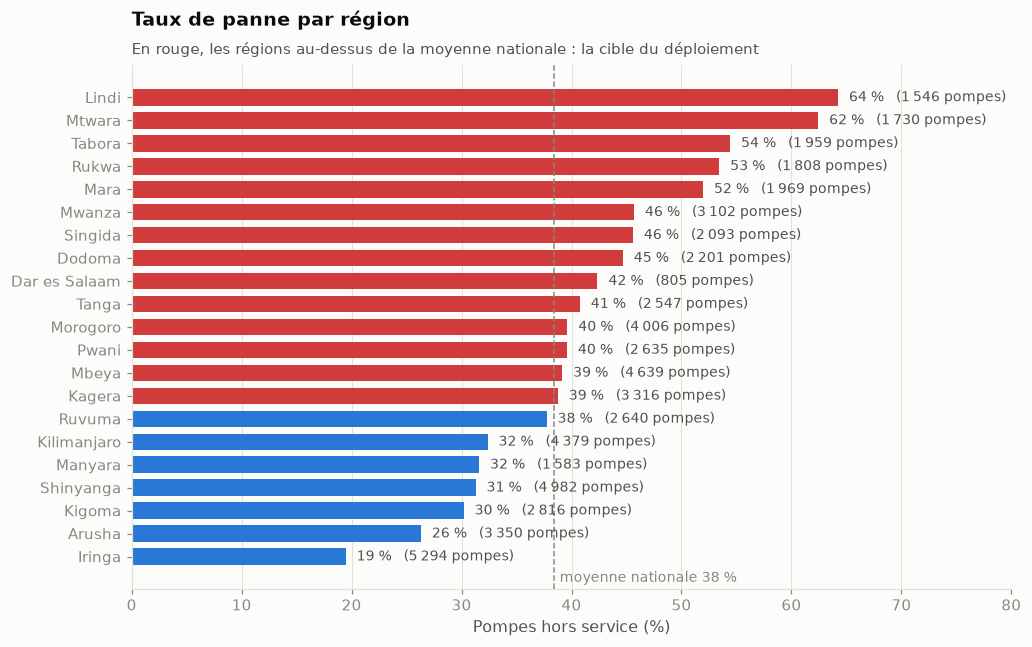

In [17]:
by_region = (train.groupby("region", observed=True)
             .agg(failure_rate=("is_non_functional", "mean"), n=("id", "size"),
                  people=("population", "sum"))
             .sort_values("failure_rate"))
by_region["failure_rate"] *= 100

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [STATUS_COLOR[NON_FUNCTIONAL] if v > national else BLUE for v in by_region.failure_rate]
ax.barh(by_region.index, by_region.failure_rate, height=0.72, color=colors)
for row, (value, n) in enumerate(zip(by_region.failure_rate, by_region.n)):
    ax.text(value + 1, row, f"{value:.0f} %   ({thousands(n)} pompes)",
            va="center", fontsize=9, color=INK_SOFT)
ax.axvline(national, color=MUTED, linestyle="--", linewidth=1)
ax.text(national + 0.5, -1.1, f"moyenne nationale {national:.0f} %", fontsize=9, color=MUTED)
titled(ax, "Taux de panne par région",
       "En rouge, les régions au-dessus de la moyenne nationale : la cible du déploiement")
ax.set_xlabel("Pompes hors service (%)")
ax.set_xlim(0, 80)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()

> **So what ?** L'écart va de **20 % à Iringa à 64 % à Lindi** — un facteur 3. Les régions du sud
> (Lindi, Mtwara) et de l'ouest (Tabora, Rukwa, Mara) cumulent les taux les plus élevés.
> Cette concentration géographique est une **bonne nouvelle opérationnelle** : elle permet de
> constituer des tournées d'équipes mobiles denses plutôt que d'éparpiller les moyens sur tout le
> territoire, ce qui réduit fortement le coût logistique par intervention.

## 4. Modélisation : prédire l'état sans se déplacer

### 4.1 Le protocole

- **Découpage** : 80 % apprentissage / 20 % validation, **stratifié** (les proportions des trois états
  sont préservées, ce qui compte vu la rareté de la classe intermédiaire).
- **Modèle** : gradient boosting (LightGBM). Choisi pour trois raisons métier autant que techniques —
  il gère nativement les **variables catégorielles** (nombreuses ici) et les **valeurs manquantes**
  (omniprésentes après neutralisation des sentinelles), et il reste **interprétable** via les
  importances et les règles apprises.
- **Références de comparaison** : un classifieur trivial (toujours « fonctionnelle ») et une
  régression logistique, pour vérifier que la complexité du modèle est justifiée.
- **Métriques** : l'exactitude seule est trompeuse avec des classes déséquilibrées. On regarde aussi
  le **F1 macro** (qui pèse les trois classes également) et surtout le **rappel sur les pompes hors
  service** — dans notre cas d'usage, rater une pompe en panne coûte bien plus cher qu'un
  déplacement inutile.

In [18]:
FIELD_ONLY_FEATURES = ["quantity", "water_quality", "amount_tsh", "log_amount_tsh"]

feature_frame = train.drop(columns=["id", "status_group", "is_non_functional", "needs_action"])
CATEGORICAL = feature_frame.select_dtypes(exclude=["number", "bool"]).columns.tolist()
NUMERIC = [c for c in feature_frame.columns if c not in CATEGORICAL]

y = train.status_group.map({s: i for i, s in enumerate(STATUS_ORDER)})
X_train, X_valid, y_train, y_valid = train_test_split(
    feature_frame, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"{len(CATEGORICAL)} variables catégorielles : {', '.join(CATEGORICAL)}")
print(f"{len(NUMERIC)} variables numériques : {', '.join(NUMERIC)}")
print(f"\nApprentissage : {len(X_train):,} · Validation : {len(X_valid):,}".replace(",", " "))

16 variables catégorielles : funder, installer, basin, region, lga, ward, public_meeting, scheme_management, permit, extraction_type, management, payment_type, water_quality, quantity, source, waterpoint_type
16 variables numériques : amount_tsh, gps_height, longitude, latitude, district_code, population, construction_year, record_year, record_month, days_since_start, pump_age, age_is_known, log_population, log_amount_tsh, ward_pumps, lga_pumps

Apprentissage : 47 520 · Validation : 11 880


### 4.2 Encodage des variables catégorielles

Certaines variables ont des milliers de modalités (`funder`, `installer`, `ward`). On plafonne aux
**60 modalités les plus fréquentes**, le reste étant regroupé dans `__other__`. Deux bénéfices :
on évite le surapprentissage sur des modalités vues 2 ou 3 fois, et une modalité absente de
l'apprentissage (fréquent sur le test) est traitée proprement au lieu de faire échouer la prédiction.

Le vocabulaire est appris **uniquement sur l'échantillon d'apprentissage**, puis appliqué tel quel à
la validation et au test : pas de fuite d'information.

In [19]:
HIGH_CARDINALITY = ["funder", "installer", "ward", "lga", "scheme_management"]
MAX_LEVELS = 60
MISSING_TOKEN, OTHER_TOKEN = "__missing__", "__other__"


def fit_category_dtypes(frame: pd.DataFrame, columns: list[str]) -> dict[str, pd.CategoricalDtype]:
    """Apprend le vocabulaire de chaque variable catégorielle sur le seul jeu d'apprentissage."""
    dtypes = {}
    for col in columns:
        values = frame[col].astype("string").fillna(MISSING_TOKEN)
        levels = values.value_counts().index
        if col in HIGH_CARDINALITY:
            levels = levels[:MAX_LEVELS]
        dtypes[col] = pd.CategoricalDtype(sorted(set(levels) | {OTHER_TOKEN, MISSING_TOKEN}))
    return dtypes


def apply_category_dtypes(frame: pd.DataFrame,
                          dtypes: dict[str, pd.CategoricalDtype]) -> pd.DataFrame:
    """Applique le vocabulaire appris ; toute modalité inconnue devient `__other__`."""
    out = frame.copy()
    for col, dtype in dtypes.items():
        values = out[col].astype("string").fillna(MISSING_TOKEN)
        out[col] = values.where(values.isin(dtype.categories), OTHER_TOKEN).astype(dtype)
    return out


category_dtypes = fit_category_dtypes(X_train, CATEGORICAL)
X_train_enc = apply_category_dtypes(X_train, category_dtypes)
X_valid_enc = apply_category_dtypes(X_valid, category_dtypes)

coverage = {c: len(category_dtypes[c].categories) for c in HIGH_CARDINALITY}
print("Modalités retenues sur les variables à forte cardinalité :", coverage)

Modalités retenues sur les variables à forte cardinalité : {'funder': 61, 'installer': 61, 'ward': 62, 'lga': 62, 'scheme_management': 13}


### 4.3 Références de comparaison

In [20]:
def score(name: str, y_true, y_pred, proba=None) -> dict:
    row = {
        "Modèle": name,
        "Exactitude": accuracy_score(y_true, y_pred),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
        "Rappel hors service": (y_pred[y_true == 2] == 2).mean(),
    }
    if proba is not None:
        row["AUC hors service"] = roc_auc_score((y_true == 2).astype(int), proba[:, 2])
    return row


def as_plain_strings(frame: pd.DataFrame) -> pd.DataFrame:
    """Variante texte des catégorielles, attendue par les encodeurs scikit-learn."""
    out = frame.copy()
    for col in CATEGORICAL:
        out[col] = out[col].astype("string").fillna(MISSING_TOKEN).astype(object)
    return out


results = []

# (a) Référence triviale : tout le monde est fonctionnel
dummy = DummyClassifier(strategy="most_frequent").fit(X_train_enc, y_train)
results.append(score("Référence triviale", y_valid, dummy.predict(X_valid_enc)))

# (b) Régression logistique sur variables encodées one-hot
logistic = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50,
                              sparse_output=True), CATEGORICAL),
    ])),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
])
logistic.fit(as_plain_strings(X_train), y_train)
X_valid_plain = as_plain_strings(X_valid)
results.append(score("Régression logistique", y_valid, logistic.predict(X_valid_plain),
                     logistic.predict_proba(X_valid_plain)))

pd.DataFrame(results).set_index("Modèle").round(3)

,Exactitude,F1 macro,Rappel hors service,AUC hors service
Modèle,,,,
Référence triviale,0.543,0.235,0.000,NaN
Régression logistique,0.769,0.608,0.713,0.884


### 4.4 Le modèle retenu : gradient boosting

Deux versions sont entraînées, et cette distinction est au cœur de l'usage opérationnel :

| Modèle | Variables utilisées | À quoi il sert |
|---|---|---|
| **Terrain** | toutes, y compris ce qui se constate sur place (`quantity`, `water_quality`, débit) | qualifier un diagnostic une fois l'équipe sur site |
| **À distance** | uniquement ce qui est connu au bureau (localisation, âge, technologie, gestion) | **décider où envoyer l'équipe** — c'est celui qui pilote la tournée |

Comparer les deux quantifie ce que « voir la pompe » apporte réellement — et évite de bâtir un plan de
tournée sur une information qui n'existe qu'*après* la visite.

In [21]:
LGBM_PARAMS = dict(
    objective="multiclass", num_class=3, n_estimators=2000, learning_rate=0.05,
    num_leaves=64, min_child_samples=20, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)


def train_lgbm(X_tr, y_tr, X_va, y_va) -> lgb.LGBMClassifier:
    """Entraîne avec arrêt anticipé sur la validation (100 itérations sans progrès)."""
    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(X_tr, y_tr, eval_X=X_va, eval_y=y_va, eval_metric="multi_logloss",
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    return model


field_model = train_lgbm(X_train_enc, y_train, X_valid_enc, y_valid)
proba_field = field_model.predict_proba(X_valid_enc)
results.append(score("Gradient boosting — terrain", y_valid, proba_field.argmax(1), proba_field))

remote_features = [c for c in X_train_enc.columns if c not in FIELD_ONLY_FEATURES]
remote_model = train_lgbm(X_train_enc[remote_features], y_train,
                          X_valid_enc[remote_features], y_valid)
proba_remote = remote_model.predict_proba(X_valid_enc[remote_features])
results.append(score("Gradient boosting — à distance", y_valid, proba_remote.argmax(1), proba_remote))

print(f"Arbres retenus — terrain : {field_model.best_iteration_} · "
      f"à distance : {remote_model.best_iteration_}")
pd.DataFrame(results).set_index("Modèle").round(3)

Arbres retenus — terrain : 481 · à distance : 558


,Exactitude,F1 macro,Rappel hors service,AUC hors service
Modèle,,,,
Référence triviale,0.543,0.235,0.000,NaN
Régression logistique,0.769,0.608,0.713,0.884
Gradient boosting — terrain,0.814,0.689,0.780,0.930
Gradient boosting — à distance,0.778,0.660,0.725,0.896


### 4.5 Robustesse : validation croisée

Un unique découpage peut être chanceux. On revalide le modèle « à distance » — celui qui pilotera les
tournées — sur **5 découpages stratifiés**, en fixant le nombre d'arbres trouvé précédemment.

In [22]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all = feature_frame[[c for c in feature_frame.columns if c not in FIELD_ONLY_FEATURES]]
cv_params = {**LGBM_PARAMS, "n_estimators": remote_model.best_iteration_}

cv_rows = []
for fold, (idx_tr, idx_va) in enumerate(folds.split(X_all, y), start=1):
    dtypes_fold = fit_category_dtypes(X_all.iloc[idx_tr],
                                      [c for c in CATEGORICAL if c in X_all.columns])
    fold_model = lgb.LGBMClassifier(**cv_params).fit(
        apply_category_dtypes(X_all.iloc[idx_tr], dtypes_fold), y.iloc[idx_tr])
    fold_proba = fold_model.predict_proba(apply_category_dtypes(X_all.iloc[idx_va], dtypes_fold))
    cv_rows.append(score(f"Fold {fold}", y.iloc[idx_va], fold_proba.argmax(1), fold_proba))

cv = pd.DataFrame(cv_rows).set_index("Modèle")
print(cv.round(3).to_string())
print("\nMoyenne ± écart-type sur 5 folds :")
print(pd.DataFrame({"moyenne": cv.mean(), "écart-type": cv.std()}).round(3).to_string())

        Exactitude  F1 macro  Rappel hors service  AUC hors service
Modèle                                                             
Fold 1       0.784     0.672                0.727             0.896
Fold 2       0.776     0.665                0.726             0.890
Fold 3       0.776     0.666                0.727             0.893
Fold 4       0.772     0.658                0.724             0.889
Fold 5       0.777     0.668                0.728             0.893

Moyenne ± écart-type sur 5 folds :
                     moyenne  écart-type
Exactitude             0.777       0.004
F1 macro               0.666       0.005
Rappel hors service    0.726       0.001
AUC hors service       0.892       0.003


### 4.6 Où le modèle se trompe-t-il ?

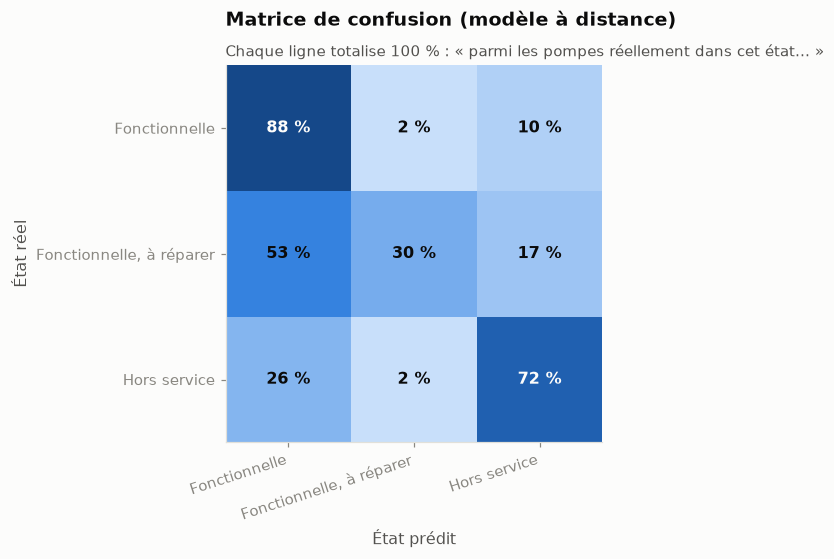

                          precision    recall  f1-score   support

           Fonctionnelle      0.777     0.878     0.825      6452
Fonctionnelle, à réparer      0.558     0.302     0.392       863
            Hors service      0.803     0.725     0.762      4565

                accuracy                          0.778     11880
               macro avg      0.713     0.635     0.660     11880
            weighted avg      0.771     0.778     0.769     11880



In [23]:
predicted = proba_remote.argmax(1)
matrix = confusion_matrix(y_valid, predicted, normalize="true") * 100

fig, ax = plt.subplots(figsize=(6.4, 5.2))
image = ax.imshow(matrix, cmap=SEQ_BLUE, vmin=0, vmax=100)
labels = [STATUS_FR[s] for s in STATUS_ORDER]
ax.set_xticks(range(3), labels, rotation=18, ha="right")
ax.set_yticks(range(3), labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matrix[i, j]:.0f} %", ha="center", va="center", fontweight="bold",
                color=SURFACE if matrix[i, j] > 55 else INK)
titled(ax, "Matrice de confusion (modèle à distance)",
       "Chaque ligne totalise 100 % : « parmi les pompes réellement dans cet état… »")
ax.set_xlabel("État prédit")
ax.set_ylabel("État réel")
ax.grid(False)
plt.tight_layout()
plt.show()

print(classification_report(y_valid, predicted, target_names=labels, digits=3))

> **Lecture métier.** Le modèle identifie correctement les pompes fonctionnelles et une large majorité
> des pompes hors service. En revanche il **échoue largement sur la classe intermédiaire**
> (« fonctionne mais à réparer ») : trop rare (7 % du parc) et trop proche de « fonctionnelle » dans
> les données disponibles. Deux conséquences assumées :
>
> 1. On ne construit **pas** de plan de maintenance préventive sur cette classe — ce serait vendre au
>    client une précision que le modèle n'a pas.
> 2. On pilote la priorisation sur une grandeur que le modèle estime bien : la **probabilité d'être
>    hors service** (AUC ≈ 0,90 à distance, 0,93 sur site), utilisée comme score continu plutôt que
>    comme classe tranchée. Un score se dose selon le budget ; une classe, non.

### 4.7 Ce qui pèse dans la décision du modèle

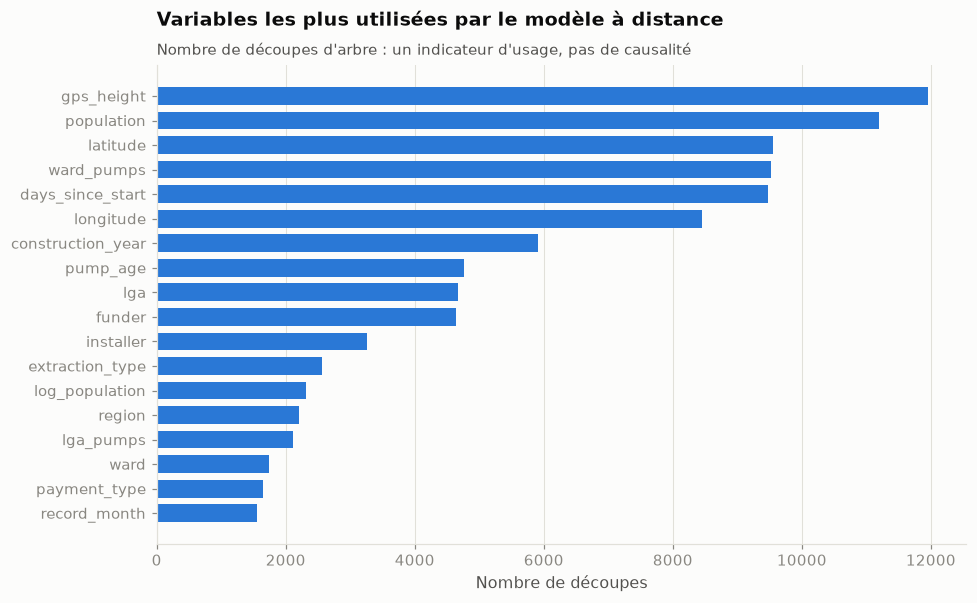

In [24]:
importance = (pd.Series(remote_model.feature_importances_, index=remote_features)
              .sort_values(ascending=False).head(18).sort_values())

fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(importance.index, importance.values, height=0.72, color=BLUE)
titled(ax, "Variables les plus utilisées par le modèle à distance",
       "Nombre de découpes d'arbre : un indicateur d'usage, pas de causalité")
ax.set_xlabel("Nombre de découpes")
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()

> **So what ?** Le trio de tête est **géographie + âge + densité locale d'équipements**. Autrement
> dit, sans même voir la pompe, sa localisation précise et son ancienneté suffisent à estimer son
> état : ce sont exactement les informations dont le Ministère dispose **avant** d'envoyer qui que ce
> soit. C'est ce qui rend la priorisation à distance possible.

## 5. De la probabilité à la tournée d'intervention

Un modèle ne répare pas une pompe. Cette section traduit les probabilités en **décisions
opérationnelles** : qui visiter en premier, et pour y faire quoi.

### 5.1 Score de priorité = risque × personnes concernées

Visiter une pompe qui a 90 % de risque d'être en panne mais qui dessert 30 personnes est moins utile
que d'en visiter une à 60 % qui en dessert 800. Le score combine donc les deux :

$$\text{priorité} = P(\text{hors service}) \times \text{population desservie}$$

La population manquante est imputée par la **médiane du ward** (à défaut, de la région, puis
nationale) : une pompe sans population renseignée n'est ni exclue ni surpondérée.

In [25]:
def estimate_population(frame: pd.DataFrame, reference: pd.DataFrame) -> pd.Series:
    """Population desservie, complétée par la médiane du ward, puis de la région, puis nationale."""
    ward_median = reference.groupby("ward", observed=True).population.median()
    region_median = reference.groupby("region", observed=True).population.median()
    national_median = reference.population.median()
    return (frame.population
            .fillna(frame.ward.map(ward_median))
            .fillna(frame.region.map(region_median))
            .fillna(national_median))


valid = train.loc[X_valid.index].copy()
valid["p_non_functional"] = proba_remote[:, 2]
valid["p_needs_attention"] = proba_remote[:, 1] + proba_remote[:, 2]
valid["population_est"] = estimate_population(valid, train.loc[X_train.index])
valid["priority_score"] = valid.p_non_functional * valid.population_est

print(f"Population imputée pour {valid.population.isna().mean():.0%} des pompes de validation")
valid.nlargest(5, "priority_score")[
    ["region", "lga", "pump_age", "population_est", "p_non_functional",
     "priority_score", "status_group"]].round(2)

Population imputée pour 36% des pompes de validation


,region,lga,pump_age,population_est,p_non_functional,priority_score,status_group
27967,Ruvuma,Songea Urban,5.0,7500.0,0.75,5658.58,non functional
20598,Pwani,Bagamoyo,37.0,6000.0,0.89,5313.93,functional
1301,Kigoma,Kigoma Urban,28.0,4655.5,0.99,4612.18,non functional
51246,Manyara,Kiteto,41.0,5000.0,0.76,3804.40,functional
29201,Mara,Rorya,10.0,5000.0,0.68,3384.51,non functional


### 5.2 Quel gain par rapport à une tournée non ciblée ?

La question que le client se pose vraiment : *« si je n'ai les moyens d'inspecter que 20 % du parc
cette année, combien de pompes en panne vais-je trouver ? »* On compare trois stratégies sur le jeu
de validation, où la vérité terrain est connue :

- **Aléatoire** — l'équipe visite au hasard (situation de référence) ;
- **Les plus vieilles d'abord** — l'heuristique naturelle sans modèle ;
- **Modèle** — tri par probabilité de panne décroissante.

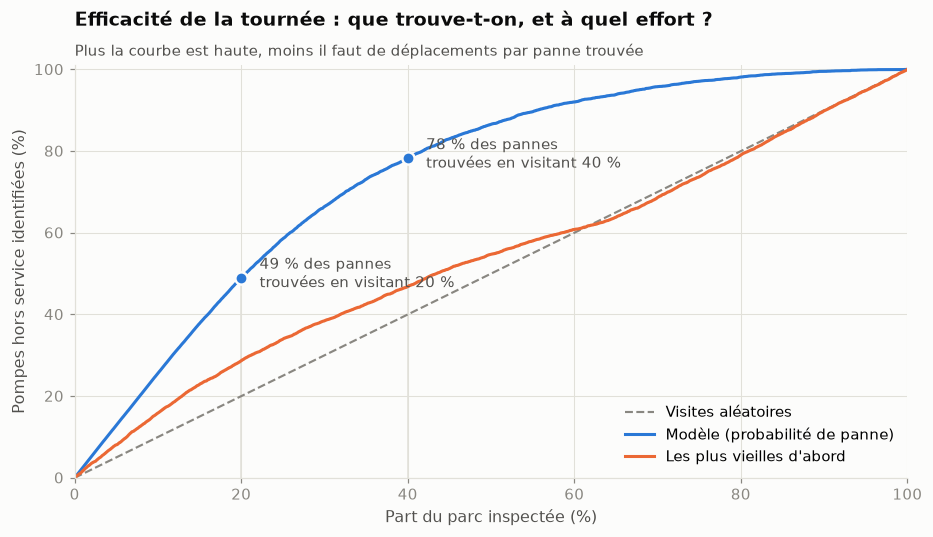

 10 % du parc inspecté → modèle  25.6 % des pannes trouvées | âge  15.9 % | aléatoire  10.0 %
 20 % du parc inspecté → modèle  48.9 % des pannes trouvées | âge  28.7 % | aléatoire  20.0 %
 30 % du parc inspecté → modèle  66.4 % des pannes trouvées | âge  38.5 % | aléatoire  30.0 %
 50 % du parc inspecté → modèle  86.6 % des pannes trouvées | âge  54.7 % | aléatoire  50.0 %


In [26]:
def coverage_curve(frame: pd.DataFrame, ranking: pd.Series, target: str) -> pd.Series:
    """Part cumulée de la cible atteinte en visitant les pompes par ordre de `ranking` décroissant."""
    ordered = frame.assign(_rank=ranking).sort_values("_rank", ascending=False)
    return ordered[target].cumsum() / frame[target].sum() * 100


visited = np.arange(1, len(valid) + 1) / len(valid) * 100
strategies = {
    "Modèle (probabilité de panne)": (coverage_curve(valid, valid.p_non_functional, "is_non_functional"), BLUE),
    "Les plus vieilles d'abord": (coverage_curve(valid, valid.pump_age.fillna(-1), "is_non_functional"), ORANGE),
}

fig, ax = plt.subplots(figsize=(8.6, 5))
ax.plot(visited, visited, color=MUTED, linestyle="--", linewidth=1.4, label="Visites aléatoires")
for label, (curve, color) in strategies.items():
    ax.plot(visited, curve.to_numpy(), color=color, linewidth=2, label=label)

for share in (20, 40):
    found = strategies["Modèle (probabilité de panne)"][0].to_numpy()[int(share / 100 * len(valid)) - 1]
    ax.plot([share, share], [0, found], color=GRID, linewidth=1, zorder=0)
    ax.plot(share, found, "o", color=BLUE, markersize=8, markeredgecolor=SURFACE, markeredgewidth=1.6)
    ax.annotate(f"{found:.0f} % des pannes\ntrouvées en visitant {share} %",
                (share, found), textcoords="offset points", xytext=(12, -6),
                fontsize=9.5, color=INK_SOFT)

titled(ax, "Efficacité de la tournée : que trouve-t-on, et à quel effort ?",
       "Plus la courbe est haute, moins il faut de déplacements par panne trouvée")
ax.set_xlabel("Part du parc inspectée (%)")
ax.set_ylabel("Pompes hors service identifiées (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

for share in (10, 20, 30, 50):
    cut = int(share / 100 * len(valid)) - 1
    model_hit = strategies["Modèle (probabilité de panne)"][0].to_numpy()[cut]
    age_hit = strategies["Les plus vieilles d'abord"][0].to_numpy()[cut]
    print(f"{share:>3} % du parc inspecté → modèle {model_hit:5.1f} % des pannes trouvées "
          f"| âge {age_hit:5.1f} % | aléatoire {share:5.1f} %")

> **So what ?** En inspectant **20 % du parc** guidé par le modèle, on retrouve **49 % des pompes
> hors service** — contre 20 % au hasard, et 29 % avec le seul critère d'âge. À budget d'inspection
> constant, c'est **2,4× plus de pannes détectées** ; formulé à l'envers, c'est la même détection
> pour **60 % de déplacements en moins**.

### 5.3 Trois interventions différentes, pas une seule

« Réparer » n'est pas une action unique. On dérive du diagnostic (§3) un arbre de décision simple,
explicable à une équipe terrain en une diapositive :

In [27]:
REPLACEMENT_AGE = 20          # au-delà, la remise à neuf coûte plus cher que le remplacement (§3.3)
FRAGILE_TECH = ["motorpump", "wind-powered", "other"]
HIGH_RISK, WATCH = 0.60, 0.35  # seuils de probabilité, ajustables selon le budget disponible


def recommend_action(frame: pd.DataFrame, risk: pd.Series) -> pd.Series:
    """Traduit un risque prédit en type d'intervention. Règles ordonnées, la première qui matche gagne."""
    old = frame.pump_age.fillna(0) >= REPLACEMENT_AGE
    fragile = frame.extraction_type_class.isin(FRAGILE_TECH) if "extraction_type_class" in frame \
        else frame.extraction_type.isin(FRAGILE_TECH)

    conditions = [
        (frame.quantity == "dry"),                       # ressource absente : la mécanique n'y peut rien
        (risk >= HIGH_RISK) & (old | fragile),           # panne probable sur équipement en fin de vie
        (risk >= HIGH_RISK),                             # panne probable sur équipement récupérable
        (risk >= WATCH),                                 # risque intermédiaire : à contrôler
    ]
    choices = [
        "1. Étude hydrogéologique",
        "2. Remplacement",
        "3. Réparation",
        "4. Inspection de contrôle",
    ]
    return pd.Series(np.select(conditions, choices, default="5. Aucune action"),
                     index=frame.index, name="action")


valid["action"] = recommend_action(
    valid.join(train_raw.set_index("id").extraction_type_class, on="id"),
    valid.p_non_functional)

action_summary = (valid.groupby("action", observed=True)
                  .agg(pompes=("id", "size"),
                       taux_de_panne_reel=("is_non_functional", "mean"),
                       personnes=("population_est", "sum"))
                  .assign(taux_de_panne_reel=lambda d: (d.taux_de_panne_reel * 100).round(1))
                  .sort_index())
action_summary

,pompes,taux_de_panne_reel,personnes
action,,,
1. Étude hydrogéologique,1325,97.4,342008.5
2. Remplacement,1457,87.7,429777.0
3. Réparation,938,73.8,224654.5
4. Inspection de contrôle,1486,40.2,401077.0
5. Aucune action,6674,10.6,1916668.5


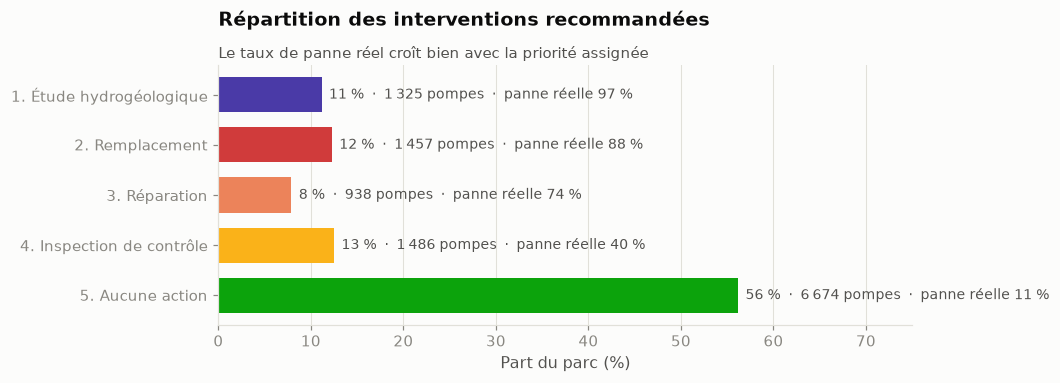

In [28]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
order = action_summary.index[::-1]
palette = {
    "1. Étude hydrogéologique": "#4a3aa7",
    "2. Remplacement": STATUS_COLOR[NON_FUNCTIONAL],
    "3. Réparation": "#ec835a",
    "4. Inspection de contrôle": STATUS_COLOR[NEEDS_REPAIR],
    "5. Aucune action": STATUS_COLOR[FUNCTIONAL],
}
share = action_summary.pompes / action_summary.pompes.sum() * 100
ax.barh(order, share[order], height=0.7, color=[palette[a] for a in order])
for row, action in enumerate(order):
    ax.text(share[action] + 0.8, row,
            f"{share[action]:.0f} %  ·  {thousands(action_summary.pompes[action])} pompes  ·  "
            f"panne réelle {action_summary.taux_de_panne_reel[action]:.0f} %",
            va="center", fontsize=9, color=INK_SOFT)
titled(ax, "Répartition des interventions recommandées",
       "Le taux de panne réel croît bien avec la priorité assignée")
ax.set_xlabel("Part du parc (%)")
ax.set_xlim(0, 75)
ax.yaxis.grid(False)
plt.tight_layout()
plt.show()

### 5.4 Chiffrage : combien de personnes reconnectées par euro investi ?

> ⚠️ **Hypothèses de coût.** Les montants ci-dessous sont des **ordres de grandeur de travail**, à
> remplacer par les coûts réels du Ministère avant toute décision budgétaire. La *méthode* — classer
> les interventions par personnes reconnectées par euro — reste valable quels que soient les montants.

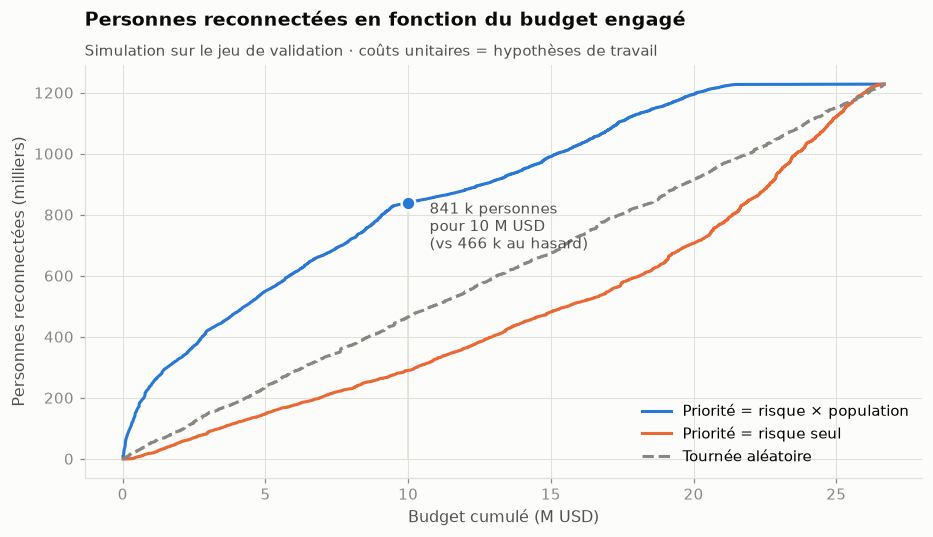

Personnes reconnectées pour un budget de 10 M USD sur ce périmètre :
  Priorité = risque × population      841 k (× 1.8 vs aléatoire)
  Priorité = risque seul              291 k (× 0.6 vs aléatoire)
  Tournée aléatoire                   466 k (× 1.0 vs aléatoire)


In [29]:
UNIT_COST_USD = {
    "1. Étude hydrogéologique": 12_000,   # forage / relocalisation
    "2. Remplacement": 6_000,
    "3. Réparation": 1_500,
    "4. Inspection de contrôle": 200,
    "5. Aucune action": 0,
}
INSPECTION_COST_USD = 200  # déplacement + diagnostic, payé même si la pompe fonctionne

valid["intervention_cost"] = valid.action.map(UNIT_COST_USD)
# Bénéfice réalisé : on ne "reconnecte" que les pompes réellement hors service
valid["people_reconnected"] = np.where(valid.is_non_functional == 1, valid.population_est, 0)
valid["total_cost"] = INSPECTION_COST_USD + np.where(
    valid.is_non_functional == 1, valid.intervention_cost, 0)


def budget_curve(ranking: pd.Series) -> pd.DataFrame:
    ordered = valid.assign(_rank=ranking).sort_values("_rank", ascending=False)
    return pd.DataFrame({
        "cost": ordered.total_cost.cumsum() / 1e6,
        "people": ordered.people_reconnected.cumsum() / 1e3,
    })


plans = {
    "Priorité = risque × population": (budget_curve(valid.priority_score), BLUE),
    "Priorité = risque seul": (budget_curve(valid.p_non_functional), ORANGE),
    "Tournée aléatoire": (budget_curve(pd.Series(
        np.random.default_rng(RANDOM_STATE).random(len(valid)), index=valid.index)), MUTED),
}

fig, ax = plt.subplots(figsize=(8.6, 5))
for label, (curve, color) in plans.items():
    ax.plot(curve.cost, curve.people, color=color, linewidth=2,
            linestyle="--" if color == MUTED else "-", label=label)

budget = 10  # M USD
reference = plans["Priorité = risque × population"][0]
reached = np.interp(budget, reference.cost, reference.people)
baseline = np.interp(budget, plans["Tournée aléatoire"][0].cost, plans["Tournée aléatoire"][0].people)
ax.plot([budget, budget], [0, reached], color=GRID, linewidth=1, zorder=0)
ax.plot(budget, reached, "o", color=BLUE, markersize=9, markeredgecolor=SURFACE, markeredgewidth=1.6)
ax.annotate(f"{reached:.0f} k personnes\npour {budget} M USD\n(vs {baseline:.0f} k au hasard)",
            (budget, reached), textcoords="offset points", xytext=(14, -30),
            fontsize=9.5, color=INK_SOFT)

titled(ax, "Personnes reconnectées en fonction du budget engagé",
       "Simulation sur le jeu de validation · coûts unitaires = hypothèses de travail")
ax.set_xlabel("Budget cumulé (M USD)")
ax.set_ylabel("Personnes reconnectées (milliers)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Personnes reconnectées pour un budget de {budget} M USD sur ce périmètre :")
for label, (curve, _) in plans.items():
    print(f"  {label:<32} {np.interp(budget, curve.cost, curve.people):6.0f} k "
          f"(× {np.interp(budget, curve.cost, curve.people) / max(baseline, 1e-9):.1f} vs aléatoire)")

> **So what ?** Le résultat le plus contre-intuitif de l'étude : pour 10 M USD engagés, le ciblage
> *risque × population* reconnecte **~840 k personnes, soit 1,8× une tournée aléatoire** — mais le
> ciblage par **risque seul fait moins bien que le hasard** (~290 k). La raison est mécanique :
> maximiser le nombre de pannes trouvées revient à dépenser le budget de réparation, poste le plus
> cher, sur les pompes les plus dégradées — souvent isolées et peu peuplées.
>
> C'est le message à porter au client : **« trouver le maximum de pannes » n'est pas l'objectif.**
> Le bon critère d'arbitrage est le nombre de personnes reconnectées par euro, et il exige de
> pondérer le risque par la population desservie. Un excellent modèle branché sur le mauvais critère
> de décision détruit de la valeur.

## 6. Livrable : le plan d'intervention

On applique la chaîne complète — nettoyage, variables dérivées, modèle, score, arbre de décision —
aux **14 850 points d'eau du jeu de test**, et on produit deux fichiers exploitables tels quels.

In [30]:
# Le modèle final est réentraîné sur 100 % des données étiquetées, au nombre d'arbres validé
final_dtypes = fit_category_dtypes(feature_frame, CATEGORICAL)
X_full = apply_category_dtypes(feature_frame, final_dtypes)[remote_features]
final_model = lgb.LGBMClassifier(
    **{**LGBM_PARAMS, "n_estimators": remote_model.best_iteration_}).fit(X_full, y)

X_test = apply_category_dtypes(test.drop(columns=["id"]), final_dtypes)[remote_features]
proba_test = final_model.predict_proba(X_test)

plan = test[["id", "region", "lga", "ward", "pump_age", "extraction_type", "quantity"]].copy()
plan["p_non_functional"] = proba_test[:, 2].round(4)
plan["predicted_status"] = [STATUS_ORDER[i] for i in proba_test.argmax(1)]
plan["population_est"] = estimate_population(test, train).round(0)
plan["priority_score"] = (plan.p_non_functional * plan.population_est).round(1)
plan["action"] = recommend_action(
    test.join(test_raw.set_index("id").extraction_type_class, on="id"), plan.p_non_functional)
plan["priority_tier"] = pd.qcut(plan.priority_score.rank(method="first"), 4,
                                labels=["P4", "P3", "P2", "P1"])
plan = plan.sort_values("priority_score", ascending=False)

plan.head(10).round(3)

,id,region,lga,ward,pump_age,extraction_type,quantity,p_non_functional,predicted_status,population_est,priority_score,action,priority_tier
6684,418,Rukwa,Mpanda,Nsimbo,1.0,other,enough,0.912,non functional,9000.0,8205.3,2. Remplacement,P1
2848,16129,Ruvuma,Songea Urban,Ruvuma,6.0,india mark ii,seasonal,0.834,non functional,7500.0,6258.8,3. Réparation,P1
7000,24223,Mara,Tarime,Matongo,18.0,other,enough,0.843,non functional,7000.0,5898.2,2. Remplacement,P1
6761,10968,Ruvuma,Songea Urban,Ruvuma,4.0,gravity,dry,0.661,non functional,7500.0,4954.5,1. Étude hydrogéologique,P1
7207,3388,Ruvuma,Songea Urban,Ruvuma,4.0,gravity,dry,0.660,non functional,7500.0,4950.8,1. Étude hydrogéologique,P1
8126,46120,Kigoma,Kigoma Urban,Gungu,28.0,other,dry,0.949,non functional,5212.0,4944.6,1. Étude hydrogéologique,P1
7652,68984,Kigoma,Kigoma Urban,Mwanga Kaskazini,23.0,other,enough,0.781,non functional,6300.0,4922.2,2. Remplacement,P1
13405,65782,Pwani,Bagamoyo,Msata,25.0,ksb,insufficient,0.918,non functional,5000.0,4591.0,2. Remplacement,P1
8964,44743,Pwani,Mkuranga,Mkuranga,1.0,other,enough,0.840,non functional,4782.0,4014.5,2. Remplacement,P1
4227,12772,Kigoma,Kasulu,Kitanga,19.0,other,enough,0.879,non functional,4500.0,3955.5,2. Remplacement,P1


In [31]:
# 1) Prédictions au format attendu par le client / la compétition DrivenData
submission = plan[["id", "predicted_status"]].rename(columns={"predicted_status": "status_group"})
submission.sort_values("id").to_csv(OUTPUT_DIR / "test_set_predictions.csv", index=False)

# 2) Plan d'intervention priorisé, exploitable par les équipes régionales
plan.to_csv(OUTPUT_DIR / "intervention_plan.csv", index=False)

print("Fichiers écrits :")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {path}  ({path.stat().st_size / 1024:.0f} Ko)")

print("\nRépartition des états prédits sur le test :")
print((submission.status_group.value_counts(normalize=True).reindex(STATUS_ORDER) * 100).round(1)
      .to_frame("part (%)").to_string())

Fichiers écrits :
  outputs/intervention_plan.csv  (1497 Ko)
  outputs/test_set_predictions.csv  (272 Ko)

Répartition des états prédits sur le test :
                         part (%)
status_group                     
functional                   61.0
functional needs repair       3.9
non functional               35.1


In [32]:
# Vue de pilotage : les 8 zones (région × LGA) où concentrer les premières tournées
priority_zones = (plan[plan.priority_tier == "P1"]
                  .groupby(["region", "lga"], observed=True)
                  .agg(pompes_prioritaires=("id", "size"),
                       risque_moyen=("p_non_functional", "mean"),
                       personnes_concernees=("population_est", "sum"))
                  .sort_values("personnes_concernees", ascending=False)
                  .head(8))
priority_zones.assign(risque_moyen=lambda d: (d.risque_moyen * 100).round(0),
                      personnes_concernees=lambda d: d.personnes_concernees.astype(int))

,,pompes_prioritaires,risque_moyen,personnes_concernees
region,lga,,,
Pwani,Mkuranga,84,57.0,116153
Kigoma,Kasulu,88,46.0,100588
Mara,Serengeti,91,53.0,98620
Shinyanga,Kahama,145,58.0,72500
Mwanza,Magu,157,79.0,60050
Ruvuma,Songea Rural,85,50.0,56711
Kigoma,Kigoma Urban,21,72.0,51958
Ruvuma,Songea Urban,16,38.0,51280


## 7. Synthèse et recommandations

### Ce que disent les données

1. **38 % du parc est hors service**, soit ~3,9 M de personnes privées de leur point d'eau principal.
2. Les pannes ne sont pas réparties au hasard : elles se concentrent sur les pompes **anciennes**,
   **motorisées**, situées dans **quelques régions** (Lindi, Mtwara, Tabora, Rukwa, Mara), et là où
   **l'eau est gratuite et le gestionnaire non identifié**.
3. Un point d'eau sur dix est simplement **à sec** : aucune réparation n'y changera quoi que ce soit.
4. Prioriser sur le **risque seul** est moins efficace qu'une tournée au hasard en personnes
   reconnectées par euro ; c'est la pondération par la population desservie qui fait la différence.

### Ce que nous recommandons

| Horizon | Action | Pourquoi |
|---|---|---|
| **Immédiat** | Déployer la tournée ciblée sur le quartile **P1** du plan d'intervention | 49 % des pannes détectées pour 20 % des déplacements |
| **Immédiat** | Sortir les points « à sec » du budget réparation, les basculer vers un programme hydrogéologique | évite des interventions sans effet |
| **6 mois** | Piloter un test contrôlé « redevance + comité de gestion » sur quelques wards | l'écart 25 % / 48 % de taux de panne justifie de tester le lien de causalité |
| **12 mois** | Réorienter les nouvelles installations vers gravitaire et pompe manuelle | moitié moins de pannes que le motorisé |
| **Continu** | Faire remonter le résultat de chaque visite dans la base | chaque tournée réentraîne le modèle et améliore la suivante |

### Limites à porter à la connaissance du client

- **Une photographie, pas un film.** Les relevés couvrent 2002-2013 avec une seule observation par
  pompe : le modèle prédit un *état*, il ne prédit pas une *date de panne future*. Passer à de la
  maintenance prédictive suppose un historique par équipement.
- **La classe « à réparer » n'est pas exploitable** (rappel faible, 7 % du parc) : nous ne
  construisons donc rien dessus.
- **La population desservie est renseignée pour 64 % du parc seulement** ; nous l'imputons par
  médiane locale, ce qui est raisonnable mais approximatif. Fiabiliser ce champ est l'amélioration au
  meilleur rapport effort/valeur pour la suite.
- **Les coûts unitaires sont des hypothèses de travail** : le chiffrage §5.4 doit être rejoué avec
  les barèmes réels avant tout arbitrage budgétaire.
- **Corrélation ≠ causalité** sur le paiement et le mode de gestion — d'où la recommandation d'un
  pilote plutôt que d'un déploiement national immédiat.